In [3]:
import pandas as pd

# Load data
df = pd.read_csv(r"C:\Users\Asus\Downloads\student\student-mat.csv", sep=';')

# Preview
print(df.head())


  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
label_cols = df.select_dtypes(include='object').columns
df[label_cols] = df[label_cols].apply(LabelEncoder().fit_transform)

# Check missing values
print(df.isnull().sum())


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [13]:
# Select features
X = df[['studytime', 'failures', 'absences', 'goout']]  # Simple features for demo
y = df['G3']

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
    
print("✅ Model trained and saved as model.pkl")
# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


✅ Model trained and saved as model.pkl
MSE: 18.378234201037603
R² Score: 0.10372144181011722


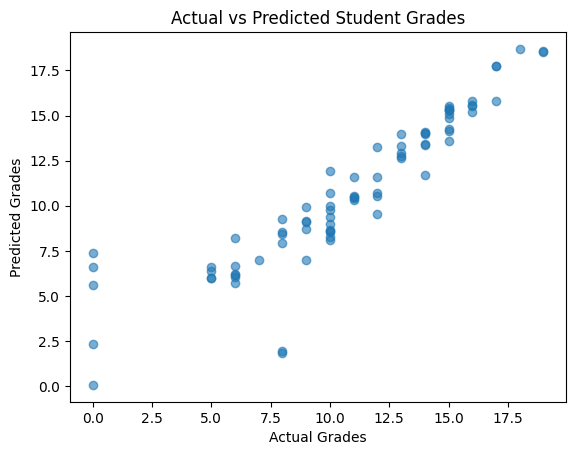

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Student Grades")
plt.show()


In [1]:
import sys
import numpy as np
import joblib
from PyQt6.QtWidgets import (
    QApplication, QWidget, QLabel, QLineEdit, QPushButton,
    QVBoxLayout, QHBoxLayout, QMessageBox
)
from PyQt6.QtGui import QFont
from PyQt6.QtCore import Qt

# Load model
try:
    model = joblib.load("model.pkl")
except Exception as e:
    print(f"Model loading error: {e}")
    sys.exit()

class StudentPerformanceApp(QWidget):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("Student Performance Predictor")
        self.setGeometry(200, 100, 450, 450)
        self.setStyleSheet("background-color: #1e1e1e; color: #f2f2f2;")
        self.inputs = {}
        self.init_ui()

    def init_ui(self):
        font_label = QFont("Segoe UI", 10, QFont.Weight.Bold)  # Bold labels
        font_title = QFont("Segoe UI", 14, QFont.Weight.Bold)
        font_button = QFont("Segoe UI", 11, QFont.Weight.Bold)

        layout = QVBoxLayout()

        title = QLabel("Student Performance Predictor")
        title.setFont(font_title)
        title.setAlignment(Qt.AlignmentFlag.AlignCenter)
        title.setStyleSheet("color: #00d4ff;")
        layout.addWidget(title)

        fields = [
            ("Study Time (1–4)", "study_time"),
            ("Failures (0–3)", "failures"),
            ("Absences (0+)", "absences"),
            ("Go Out Frequency (1–5)", "go_out")
        ]

        for label_text, key in fields:
            hbox = QHBoxLayout()
            label = QLabel(label_text)
            label.setFont(font_label)
            line_edit = QLineEdit()
            line_edit.setFont(QFont("Segoe UI", 10))
            line_edit.setStyleSheet("padding: 5px; background-color: #2e2e2e; color: white;")
            self.inputs[key] = line_edit
            hbox.addWidget(label)
            hbox.addWidget(line_edit)
            layout.addLayout(hbox)

        # Button layout
        btn_layout = QHBoxLayout()

        # Predict button
        predict_btn = QPushButton("Predict Grade")
        predict_btn.setFont(font_button)
        predict_btn.setStyleSheet("background-color: #007acc; color: white; padding: 10px; border-radius: 6px;")
        predict_btn.clicked.connect(self.predict)
        btn_layout.addWidget(predict_btn)

        # Clear button
        clear_btn = QPushButton("Clear")
        clear_btn.setFont(font_button)
        clear_btn.setStyleSheet("background-color: #c0392b; color: white; padding: 10px; border-radius: 6px;")
        clear_btn.clicked.connect(self.clear_fields)
        btn_layout.addWidget(clear_btn)

        # Exit button
        exit_btn = QPushButton("Exit")
        exit_btn.setFont(font_button)
        exit_btn.setStyleSheet("background-color: #555; color: white; padding: 10px; border-radius: 6px;")
        exit_btn.clicked.connect(self.close)  # This closes the app
        btn_layout.addWidget(exit_btn)

        layout.addLayout(btn_layout)

        # Result label
        self.result_label = QLabel("")
        self.result_label.setFont(QFont("Segoe UI", 11, QFont.Weight.Bold))
        self.result_label.setAlignment(Qt.AlignmentFlag.AlignCenter)
        self.result_label.setStyleSheet("margin-top: 15px; color: #00ff88;")
        layout.addWidget(self.result_label)

        self.setLayout(layout)

    def predict(self):
        try:
            values = [float(self.inputs[key].text()) for key in self.inputs]
            prediction = model.predict([np.array(values)])
            g3 = round(prediction[0], 2)
            self.result_label.setText(f"Predicted Final Grade (G3): {g3}")
        except ValueError:
            QMessageBox.warning(self, "Input Error", "Please enter valid numeric values.")
        except Exception as e:
            QMessageBox.critical(self, "Error", f"An unexpected error occurred:\n{e}")

    def clear_fields(self):
        for input_field in self.inputs.values():
            input_field.clear()
        self.result_label.setText("")

if __name__ == "__main__":
    app = QApplication(sys.argv)
    window = StudentPerformanceApp()
    window.show()
    try:
        sys.exit(app.exec())
    except SystemExit:
        pass  # Suppress the SystemExit traceback in Jupyter/IPython